<a href="https://colab.research.google.com/github/yuningrumzattayu/Pengembangan-Machine-Learning/blob/main/Analisis_Sentiment_menggunakan_LSTMipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Embedding, LSTM, Dropout, Conv1D, MaxPooling1D, BatchNormalization
from tensorflow.keras.callbacks import ReduceLROnPlateau

from warnings import filterwarnings
filterwarnings('ignore')

In [ ]:
clean_df = pd.read_csv('data_cleaned.csv')

In [ ]:
clean_df = clean_df.dropna()
print("Jumlah Ulasan", clean_df.shape[0])

Jumlah Ulasan 12000


In [ ]:
sentiment = pd.get_dummies(clean_df['sentimen']).astype(int)
final_df = pd.concat([clean_df, sentiment], axis=1)
final_df = final_df.drop(columns='sentimen')
final_df

,reviews,text_clean,text_casefoldingText,text_slangwords,text_tokenizingText,text_stopword,text_akhir,polarity_score,polarity,sentimen_score,negative,neutral,positive
0,"Aplikasi sangat jelek, mengecewakan, sdh uppda...",Aplikasi sangat jelek mengecewakan sdh uppdate...,aplikasi sangat jelek mengecewakan sdh uppdate...,aplikasi sangat jelek mengecewakan sdh uppdate...,"['aplikasi', 'sangat', 'jelek', 'mengecewakan'...","['aplikasi', 'jelek', 'mengecewakan', 'sdh', '...",aplikasi jelek mengecewakan sdh uppdate aktifk...,-15,negative,-15,1,0,0
1,kalo ke aplikasi provider sendiri kasih data l...,kalo ke aplikasi provider sendiri kasih data l...,kalo ke aplikasi provider sendiri kasih data l...,kalau ke aplikasi provider sendiri kasih data ...,"['kalau', 'ke', 'aplikasi', 'provider', 'sendi...","['aplikasi', 'provider', 'kasih', 'data', 'bia...",aplikasi provider kasih data biar akses lahh d...,-20,negative,-20,1,0,0
2,Ini kenapa sih XL jaringannya jadi lemot bahka...,Ini kenapa sih XL jaringannya jadi lemot bahka...,ini kenapa sih xl jaringannya jadi lemot bahka...,ini kenapa sih xl jaringannya jadi lambat bahk...,"['ini', 'kenapa', 'sih', 'xl', 'jaringannya', ...","['xl', 'jaringannya', 'lambat', 'ilang²an', 's...",xl jaringannya lambat ilang²an salah kuota sek...,-8,negative,-8,1,0,0
3,gatau ya xl kok lemot banget ngisi paket di ap...,gatau ya xl kok lemot banget ngisi paket di ap...,gatau ya xl kok lemot banget ngisi paket di ap...,gatau iya xl kok lambat banget mengisi paket d...,"['gatau', 'iya', 'xl', 'kok', 'lambat', 'bange...","['gatau', 'xl', 'lambat', 'banget', 'mengisi',...",gatau xl lambat banget mengisi paket aplikasi ...,-11,negative,-11,1,0,0
4,Tidak ada pemberitahuan update mengenai fitur ...,Tidak ada pemberitahuan update mengenai fitur ...,tidak ada pemberitahuan update mengenai fitur ...,tidak ada pemberitahuan update mengenai fitur ...,"['tidak', 'ada', 'pemberitahuan', 'update', 'm...","['pemberitahuan', 'update', 'fitur', 'aplikasi...",pemberitahuan update fitur aplikasi tetiba fit...,-32,negative,-32,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11995,bagus meskipun kecil kuota yg bisa internetan👍,bagus meskipun kecil kuota yg bisa internetan,bagus meskipun kecil kuota yg bisa internetan,bagus meskipun kecil kuota yang bisa internetan,"['bagus', 'meskipun', 'kecil', 'kuota', 'yang'...","['bagus', 'kuota', 'internetan']",bagus kuota internetan,-4,negative,-4,1,0,0
11996,Yang di perbaiki harusnya bukan sistem nya tp ...,Yang di perbaiki harusnya bukan sistem nya tp ...,yang di perbaiki harusnya bukan sistem nya tp ...,yang di perbaiki harusnya bukan sistem nya tap...,"['yang', 'di', 'perbaiki', 'harusnya', 'bukan'...","['perbaiki', 'sistem', 'developernya', 'aplika...",perbaiki sistem developernya aplikasi layak de...,-6,negative,-6,1,0,0
11997,kalo buka apk suka lemot. padahal sinyal full....,kalo buka apk suka lemot padahal sinyal full t...,kalo buka apk suka lemot padahal sinyal full t...,kalau buka aplikasi suka lambat padahal sinyal...,"['kalau', 'buka', 'aplikasi', 'suka', 'lambat'...","['buka', 'aplikasi', 'suka', 'lambat', 'sinyal...",buka aplikasi suka lambat sinyal full apa-apa ...,3,positive,3,0,0,1
11998,Xl tolong di perbaiki aplikasinya saya tidak b...,Xl tolong di perbaiki aplikasinya saya tidak b...,xl tolong di perbaiki aplikasinya saya tidak b...,xl tolong di perbaiki aplikasinya saya tidak b...,"['xl', 'tolong', 'di', 'perbaiki', 'aplikasiny...","['xl', 'tolong', 'perbaiki', 'aplikasinya', 'm...",xl tolong perbaiki aplikasinya mem buka xl men...,-2,negative,-2,1,0,0


In [ ]:
X = final_df['text_akhir'].values
y = final_df[['negative',	'neutral',	'positive']].values

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

print(X_train.shape)
print(X_test.shape)

(9600,)
(2400,)


In [ ]:
tokenizer = Tokenizer(num_words=50000, oov_token='<OOV>')

tokenizer.fit_on_texts(X_train)
tokenizer.fit_on_texts(X_train)

sequence_train = tokenizer.texts_to_sequences(X_train)
sequence_test = tokenizer.texts_to_sequences(X_test)

padded_train = pad_sequences(sequence_train, padding='post', maxlen=50, truncating='post')
padded_test = pad_sequences(sequence_test, padding='post', maxlen=50, truncating='post')

In [ ]:
model = Sequential([
    Embedding(input_dim=50000, output_dim=16, input_length=50),
    Conv1D(32, kernel_size=3, activation='relu', padding='same'),
    LSTM(64, return_sequences=True),
    LSTM(32, return_sequences=True),
    LSTM(32),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(3, activation='softmax')
])

In [ ]:
model.compile(loss='categorical_crossentropy', optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.0005), metrics=['accuracy'])

In [ ]:
class myCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        if(logs.get('accuracy') > 0.85 and logs.get('val_accuracy') > 0.85):
          print("\nAkurasi telah mencapai >85%")
          self.model.stop_training = True

callbacks = myCallback()

In [ ]:
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

history = model.fit(
    padded_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_data=(padded_test, y_test),
    callbacks=[callbacks, reduce_lr]
)

Epoch 1/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 29s 78ms/step - accuracy: 0.7124 - loss: 0.7611 - val_accuracy: 0.7183 - val_loss: 0.7327 - learning_rate: 5.0000e-04
Epoch 2/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 41s 79ms/step - accuracy: 0.7255 - loss: 0.7164 - val_accuracy: 0.7183 - val_loss: 0.7333 - learning_rate: 5.0000e-04
Epoch 3/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 41s 80ms/step - accuracy: 0.7162 - loss: 0.7279 - val_accuracy: 0.7183 - val_loss: 0.7343 - learning_rate: 5.0000e-04
Epoch 4/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 23s 76ms/step - accuracy: 0.7267 - loss: 0.7098 - val_accuracy: 0.7183 - val_loss: 0.7340 - learning_rate: 5.0000e-04
Epoch 5/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 41s 76ms/step - accuracy: 0.7197 - loss: 0.7193 - val_accuracy: 0.7183 - val_loss: 0.7324 - learning_rate: 5.0000e-04
Epoch 6/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 42s 80ms/step - accuracy: 0.7137 - loss: 0.7324 - val_accuracy: 0.7183 - val_loss: 0.7404 - learning_rate: 5.0000e-04
Epoch 7/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 40s 78ms/ste

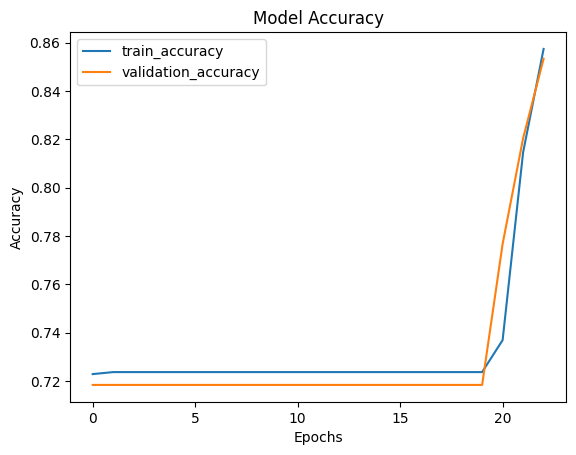

In [ ]:
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='validation_accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

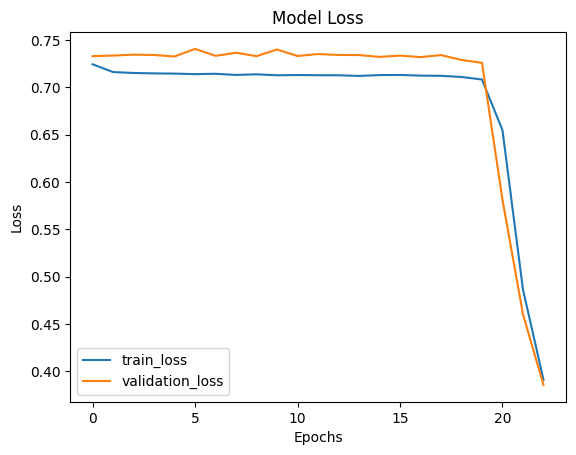

In [ ]:
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='validation_loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()